Ce TP est dans la continuité des opérations élémentaires déjà effectuées sur les images. Il revient sur la notion de filtre. C'est un aspect essentiel du traitement d'images qui consiste à améliorer la qualité d'image en réduisant au maximum le bruit. C'est aussi un aspect important historiquement du traitement de l'image, qui a notamment inspiré l'architecture des réseaux de neurones de type CNN.

Dans ce TP, nous allons approfondir cette catégorie de techniques, en mettant l'accent sur le concept de filtre linéaire ou non linéaire. 

Une utilisation spécifique et assez exhaustive de scikit-image est inscrite au programme de cette formation. Ainsi on se forcera occasionnellement, de manière mesurée, à utiliser les fonctions de cette bibliothèque. Il faut bien comprendre que certaines opérations (chargement de l'image, affichage de l'image, conversion en niveau de gris...) sont réalisables avec plusieurs des librairies. Et les filtres, en particulier, peuvent être importés de PIL ou de skimage.

<font color="orange"> Regrouper les imports dans la cellule suivante. Pour commencer, importer le module io de skimage. </font> Attention, ce module utilise d'autres bibliothèques, dont celles déjà vues ! Par exemple, matplotlib.pyplot est utilisé dans la fonction imshow de io. Nous ne sommes donc pas en territoire inconnu avec une nouvelle librairie, mais ces bibliothèques font partie des requirements, il faut donc les installer si elles venaient à être absentes de l'environnement utilisé. Pour ce TP, ces dépendances sont matplotlib, numpy et pil. Pour utiliser certaines fonctionnalités de scikit-image, on peut être amené à utiliser également scipy et six.

In [1]:
from skimage import io, exposure, color, feature
import matplotlib.pyplot as plt
import numpy as np

### Préparation de l'image

Réalisons rapidement les étapes déjà abordées, en se forçant à utiliser scikit-image.

<font color="orange">Importer une des images présentes dans le dossier sous forme d’un vecteur numpy.</font> Utiliser pour cela la fonction imread de io.

In [2]:
img_array = io.imread(r'../../data/bateau.jpg')

<font color="orange">Afficher l'image à partir de cette variable numpy array.</font> Les fonctions de io pour faire cela ont exactement le même nom que celles de plt.

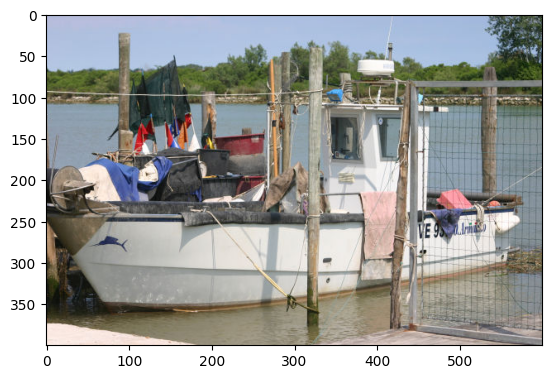

In [3]:
plt.imshow(img_array)
plt.show()

Voici une fonction permettant d'afficher les histogrammes des 3 canaux de couleur (il est aussi possible de réutiliser du code des TP précédents pour la recoder). L'appeler sur l'image d'origine.

In [4]:
def plot_channel_hists(image: np.ndarray) -> None:
    """Plot the pixel bar chart of the three channels."""
    _, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    channels = ["red", "green", "blue"]
    for i, canal in enumerate(channels):
        hist = exposure.histogram(image[:, :, i])
        axs[i].plot(hist[0])
        axs[i].set_title(canal)

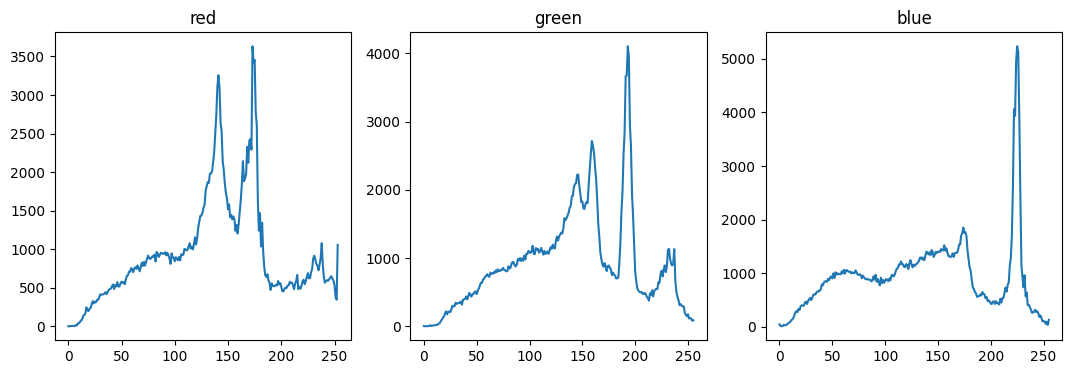

In [5]:
plot_channel_hists(img_array)

<font color="orange">Convertir l'image en niveaux de gris (encore une fois essayer d'utiliser une fonction de scikit-learn ; le module pertinent est ici color) et l'afficher.</font>

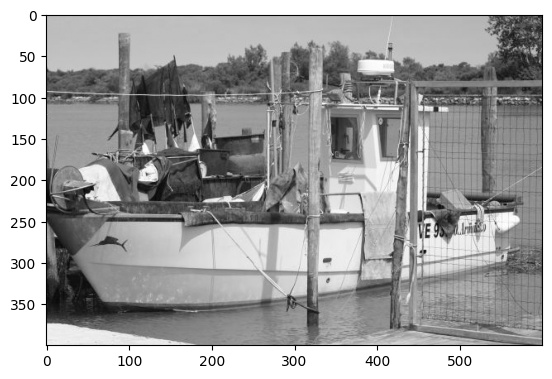

In [6]:
img_gray_array = color.rgb2gray(img_array)
plt.imshow(img_gray_array, cmap="gray")
plt.show()

### Premier "filtre" inconnu : Canny.

Dans ce premier cas, l'objet à importer se trouve dans le module feature de scikit-learn.

<font color="orange">Essayer d'appliquer la fonction canny de ce module feature à l'image en couleurs (sous forme numpy array). Que constate-t-on ?</font>

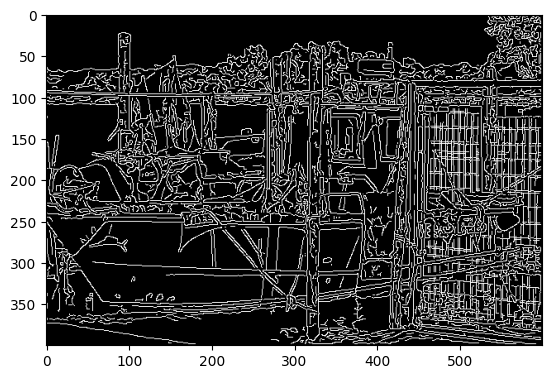

In [7]:
img_canny_array = feature.canny(img_gray_array, sigma=1)
plt.imshow(img_canny_array, cmap="gray")
plt.show()

<font color="orange">En interprétant le message d'erreur (et/ou en consultant la documentation de feature_canny, mais cela spoilera son effet), proposer une solution et l'implémenter.</font>

<font color="green">Il faut convertir l'image en niveaux de gris.</font>

In [8]:
# Votre code ici

<font color="orange">Conjecturer la nature du filtre (que cherche-t-il à détecter) ? Quelle peut en être l'application ?</font>

<font color="green">Le filtre réalise une détection de contours. Cela peut aider à la détection d'objets.</font>

### Manipulation de (vrais) filtres : filtres linéaires et non linéaires

Ces filtres s'appliquent sur les images RGB.

<font color="orange">Ajouter dans les imports le module de skimage qui semble le plus pertinent pour cette section.</font>

Il existe diverses méthodes de filtrage selon le type de bruit que l'on souhaite réduire. Le lissage par moyennage est une technique utilisant un filtre linéaire, appartenant ainsi à la catégorie de filtrage la plus élémentaire.

Pour mieux comprendre cette notion, revenons d'abord à la définition de linéarité. Un opérateur G est qualifié de linéaire s'il satisfait à deux propriétés fondamentales :

    (1) Additivité : Pour deux fonctions u et v, G(u+v) = G(u) + G(v).
    (2) Homogénéité : Pour une fonction u et une constante λ, G(λu) = λG(u).

En traitement d'images, et plus généralement en traitement du signal, un filtre linéaire est un système qui transforme une image en utilisant un opérateur linéaire. Cette transformation est généralement appliquée localement. Une caractéristique essentielle des filtres linéaires est l'invariance par translation, ce qui signifie que la modification d'un pixel dépend de son voisinage, et non de sa position dans l'image.

Le lissage par moyennage utilise un filtre linéaire spécifique appelé filtre moyenneur. En effet, l'opération appliquée à une image initiale représentée sous forme matricielle X pour obtenir une image débruitée Y consiste en des opérations d'addition et de division :

$ Y_{i,j} = \frac{X_{i−1,j−1} + X_{i−1,j} + X_{i−1,j+1} + X_{i,j−1} + X_{i,j} + X_{i,j+1} + X_{i+1,j−1} + X_{i+1,j} + X_{i+1,j+1}}{9} $

#### L'opérateur de convolution

Un filtre linéaire altère la valeur de chaque pixel dans une image en utilisant une combinaison linéaire des niveaux de gris des pixels voisins. Cette transformation est réalisée au moyen d'un opérateur appelé produit de convolution, d'où le terme "filtrage par convolution". On note traditionnellement l'opérateur de convolution $∗$. La relation mathématique qui décrit la transformation de l'image originale X en l'image filtrée Y pour n'importe quel type de filtre linéaire peut être formulée : $ Y = H ∗ X $. En d'autres termes, cela équivaut à mettre à jour la valeur de chaque pixel de la manière suivante :

$Y_{i,j} = \sum \limits_{u=−k}^{k} \sum \limits_{v=−k}^{k} H_{u,v} X_{i−u,j−v}$

$H$ représente le noyau de convolution, parfois appelé masque. Ce noyau est une matrice carrée de dimension $2k+1$ qui définit les propriétés du filtre linéaire appliqué. Le processus de filtrage par convolution consiste schématiquement à parcourir l'image à l'aide d'une fenêtre d'analyse de dimension définie, positionnée de manière centrée sur le pixel que l'on souhaite modifier.

Cependant, qu'en est-il des pixels situés sur les bords de l'image ?

Il est possible que vous ayez déjà remarqué une limitation du produit de convolution : cette opération ne peut pas être directement appliquée aux pixels en périphérie de l'image. Par conséquent, des traitements spécifiques doivent être appliqués à ces pixels.

Plusieurs approches sont envisageables : attribuer une valeur uniforme, telle que 0 (noir), à tous les pixels en bordure, ce qui peut donner à l'image filtrée un contour monochrome, ou réaliser une convolution partielle en utilisant les pixels voisins disponibles. Dans tous les cas, il est généralement préférable de ne pas réduire la taille de l'image.

### Petit exercice

On considère l'image $ I = \begin{bmatrix} 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 \end{bmatrix} $ et le noyau $ H = \begin{bmatrix} a & b & c \\ d & e & f \\ g & h & i \end{bmatrix} $.

<font color="orange">Que vaut </font>$ H∗I $<font color="orange"> ?</font>

In [9]:
from skimage import filters

### Filtre moyen

<font color="orange">Proposer une matrice de convolution carrée de taille 3 pour effectuer un lissage par moyenne.</font>

In [10]:
# Votre code ici

En pratique pour effectuer un lissage de cette nature, on emploiera plutôt un filtre gaussien ou un filtre médian (qui est lui non linéaire).

#### Filtre médian

<font color="orange">Appliquer à l'image le filtre MEDIAN et observer le résultat.</font>

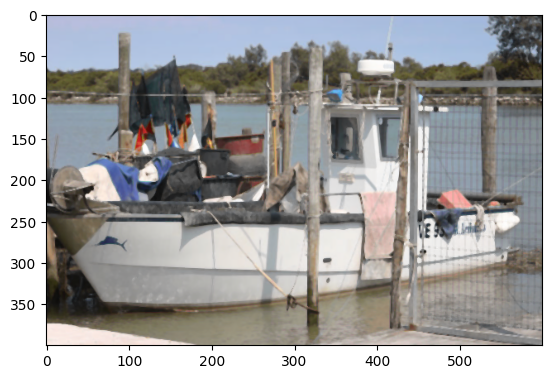

In [11]:
median_array = filters.median(img_array)
plt.imshow(median_array)
plt.show()

<font color="orange">De quelle taille est la matrice de convolution ayant été appliquée ? Appliquer une matrice de convolution de taille 7 et observer la différence.</font>

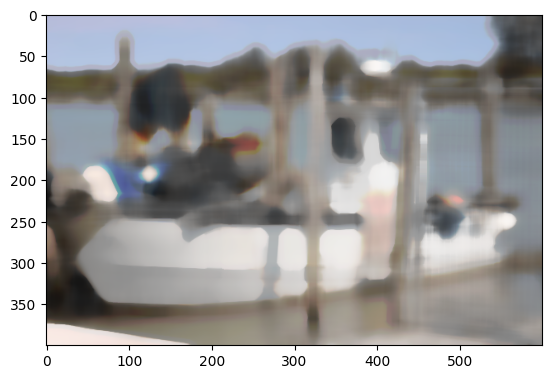

In [12]:
median_array = filters.median(img_array, footprint=np.ones((20, 20, 3)))
plt.imshow(median_array)
plt.show()

En repartant de la fonction précédente, nous avons créé une nouvelle fonction permettant d'afficher les deux histogrammes superposés sur le même graphe. L'utiliser pour visualiser l'effet du filtre median (en utilisant la taille de matrice de convolution donnant l'image la plus nette).

In [13]:
def plot_channel_hists_duo(image: np.ndarray, filtered_image: np.ndarray, filter_name: str) -> None:
    """Plot the pixel bar chart of the three channels for both the
    original and the filtered images.
    """
    _, axs = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    channels = ["red", "green", "blue"]
    for i, canal in enumerate(channels):
        hist_origin = exposure.histogram(image[:, :, i])
        hist_filtered = exposure.histogram(filtered_image[:, :, i])
        axs[i].plot(hist_origin[0], label="Original image.")
        axs[i].plot(hist_filtered[0], label=f"Filtered image - {filter_name} filter.")
        axs[i].set_title(canal)
        if i == 0:
            axs[i].legend()

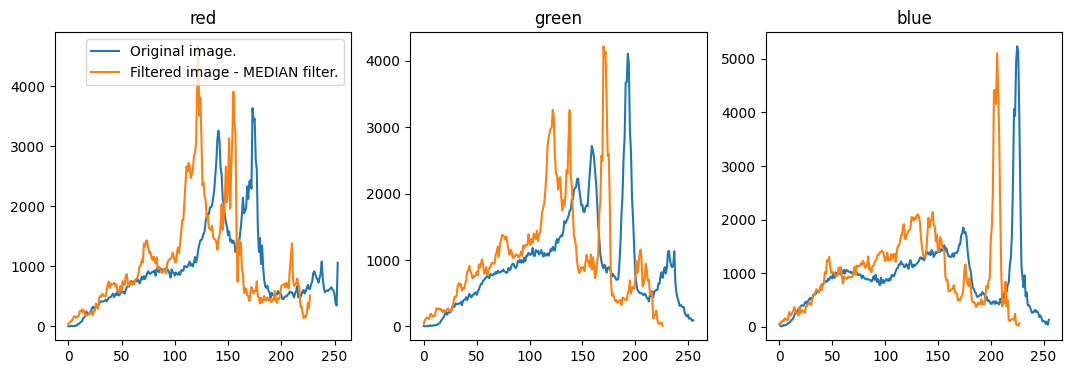

In [14]:
plot_channel_hists_duo(img_array, median_array, "MEDIAN")

Nous venons de constater l'effet sur une image "normale", mais le filtre n'est pas un franc succès : il a l'air de plutôt dégrader la qualité de l'image. <font color="orange">Essayer d'imaginer dans quelle situation un tel filtre peut avoir une utilité.</font>

Parfois, certaines images présentent des défauts d'encodage, pour une diversité de raisons possibles (problème matériel, contamination du fichier...). Nous pourrions récupérer une image présentant tels défauts mais, pour nous entraîner à manipuler nos tableaux numpy, prenons plutôt le parti de générer une image synthétique de notre bateau pour simuler ces problèmes. Pour cela nous allons créer, à partir de l'image en niveaux de gris, une image "sel et poivre", parsemée de pixels blancs et noirs symbolisant ces défauts.

Un "masque" est un tableau numpy de même taille que l'image, constituée uniquement de 0 (Faux) et de 1 (Vrai), indiquant un futur traitement à appliquer.

<font color="orange">En tirant aléatoirement les pixels concernés avec une fréquence avoisinant les 1%, créer un premier masque de l'image pour représenter un ensemble de pixels qui vont être altérés en pixels noirs. Créer un second masque équivalent pour les pixels blancs.</font> Il est recommandé d'utiliser le module np.random.

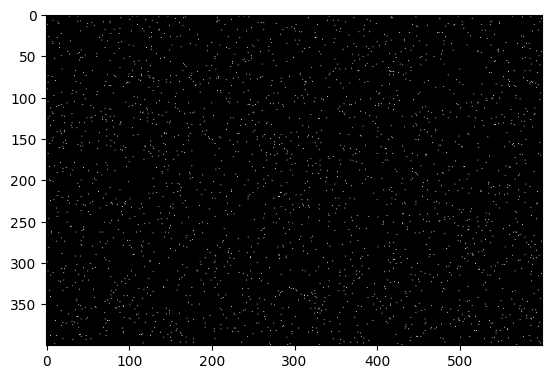

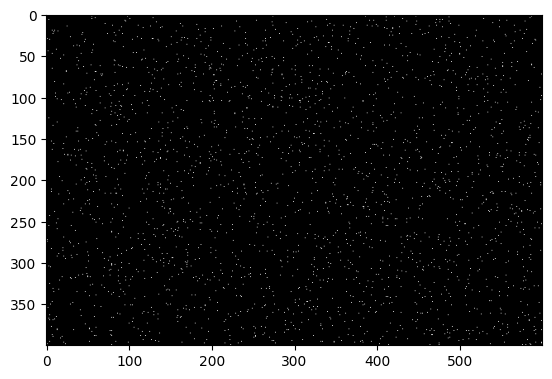

In [15]:
rng = np.random.default_rng()
black_mask = rng.binomial(n=1, p=0.01, size=img_gray_array.shape)
plt.imshow(black_mask, cmap="gray")
plt.show()
white_mask = rng.binomial(n=1, p=0.01, size=img_gray_array.shape)
plt.imshow(white_mask, cmap="gray")
plt.show()

<font color="orange">A l'aide de np.where, appliquer les deux altérations successives à l'image en niveaux de gris, afin d'obtenir une image "sel et poivre". Afficher l'image qui en résulte.</font>

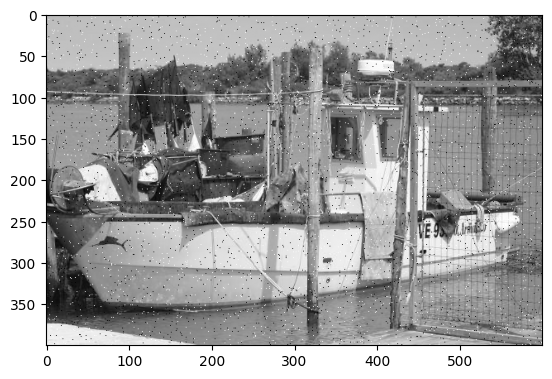

In [16]:
masked_array = np.where(black_mask, 0, img_gray_array)
masked_array = np.where(white_mask, 1, masked_array)
plt.imshow(masked_array, cmap="gray")
plt.show()

<font color="orange">Appliquer désormais le filtre median à l'image sel et poivre et afficher le résultat.</font>

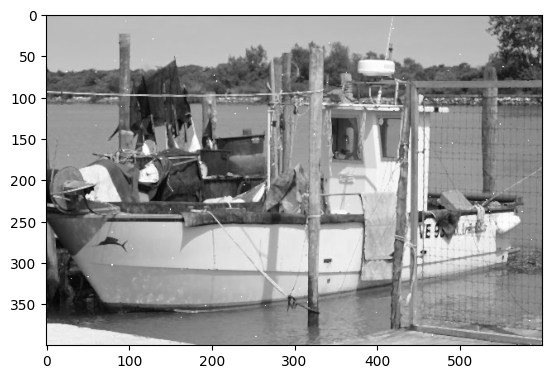

In [17]:
median_array = filters.median(masked_array, footprint=np.ones((2, 2)))
plt.imshow(median_array, cmap="gray")
plt.show()

In [18]:
mean_array = filters.rank.mean(masked_array, footprint=np.ones((2, 2)))
plt.imshow(gauss_array, cmap="gray")
plt.show()

C:\Users\orsys\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3699: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


NameError: name 'gauss_array' is not defined

#### Filtre gaussien

Un filtre gaussien est un filtre linéaire dont les valeurs des éléments dans le noyau de convolution sont déterminées en fonction de la distribution de probabilité gaussienne bidimensionnelle centrée :

$ h(x,y) = \frac{1}{2 \pi \sigma^2} e^{- \frac{x^2 + y^2}{2 \sigma^2}} $

Étant donné que le noyau de convolution doit avoir un nombre limité d'éléments, nous devons créer une version discrète de l'approximation de la densité gaussienne. La densité gaussienne est une fonction continue strictement positive sur l'ensemble des réels. Dans la pratique, on effectue souvent un échantillonnage de cette fonction sur l'intervalle $ ]-3 \sigma, 3 \sigma[ $ (la fonction est négligeable en dehors de cette plage).

En outre, le filtre gaussien est séparable, ce qui signifie que son noyau peut être décomposé en un produit de deux noyaux plus simples. En effet, on peut exprimer la fonction gaussienne bidimensionnelle comme le produit de deux fonctions unidimensionnelles : $ e^{- \frac{x^2 + y^2}{2 \sigma^2}} = e^{- \frac{x^2}{2 \sigma^2}} e^{- \frac{y^2}{2 \sigma^2}} $. Cette propriété permet d'effectuer la convolution 2D de manière plus efficace : on applique d'abord une convolution gaussienne unidimensionnelle sur les lignes de l'image, puis une autre convolution sur les colonnes.

En synthèse, si on devait concevoir le noyau d'un filtre gaussien from scratch (ce qu'on ne fera pas en pratique), on suivrait le processus suivant :

- Choix de la taille du noyau H (l'entier impair le plus proche de $ 6 \sigma $).
- Calcul des vecteurs $ H_x $ et $ H_y $ (on calcule les valeurs $ h_i = \frac{1}{2 \pi \sigma^2}  e^{\frac{-i^2}{2 \sigma^2}} $ pour i allant de 0 à k, et symétriquement, $ h_{-i} = h_i $.
- Normalisation (chaque coefficient est divisé par la somme de tous les poids $ h_i $).

En particulier, la normalisation permet d'interpréter ce filtre comme un filtre moyenneur amélioré : chaque pixel est acorrigé grâce à une moyenne pondérée.

<font color="orange">Reprendre avec le filtre gaussien les mêmes questions que celles traitées dans le cadre du filtre médian (sans regénérer l'image sel et poivre).</font>

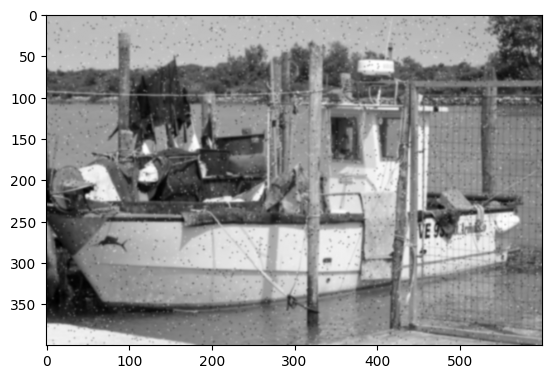

In [ ]:
gauss_array = filters.gaussian(masked_array, sigma=1)
plt.imshow(gauss_array, cmap="gray")
plt.show()

Ici on observe un résultat moins convaincant que pour le filtre médian. En fonction des paramètres, il peut être plus fou et/ou corriger moins de défauts.

La performance du filtre gaussien est étroitement liée à la valeur de sa variance : lorsque l'image est plus bruitée, il est nécessaire d'augmenter la variance, mais cela se traduit par une image de plus en plus floue. Il est intéressant de noter que tout filtre linéaire agit sur une image bruitée comme suit :

$ G(I+η)(x,y)=G(I)(x,y)+G(η)(x,y) $
 

Le terme $ G(η)(x,y) $ est particulièrement pertinent : une somme pondérée de n gaussiennes, toutes avec la même variance $ \sigma^2 $, demeure une gaussienne, mais avec une variance réduite de $ \frac{\sigma^2}{n} $. Cela permet d'atténuer le bruit, et lorsque $ n $ augmente, le bruit tend à diminuer, mais l'image obtenue n'est (malheureusement) pas identique à l'image originale $ I $ : il s'agit d'une version lissée $ G(I) $, d'où le flou résultant. Ce problème est inhérent aux filtres linéaires.

### Image matching

Lorsqu'on effectue une recherche d'images d'un objet unique particulier, on s'attend bien naturellement à ce que les résultats le présentent sous des formes variées.

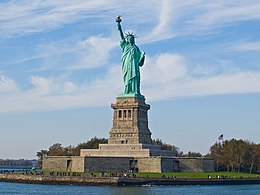
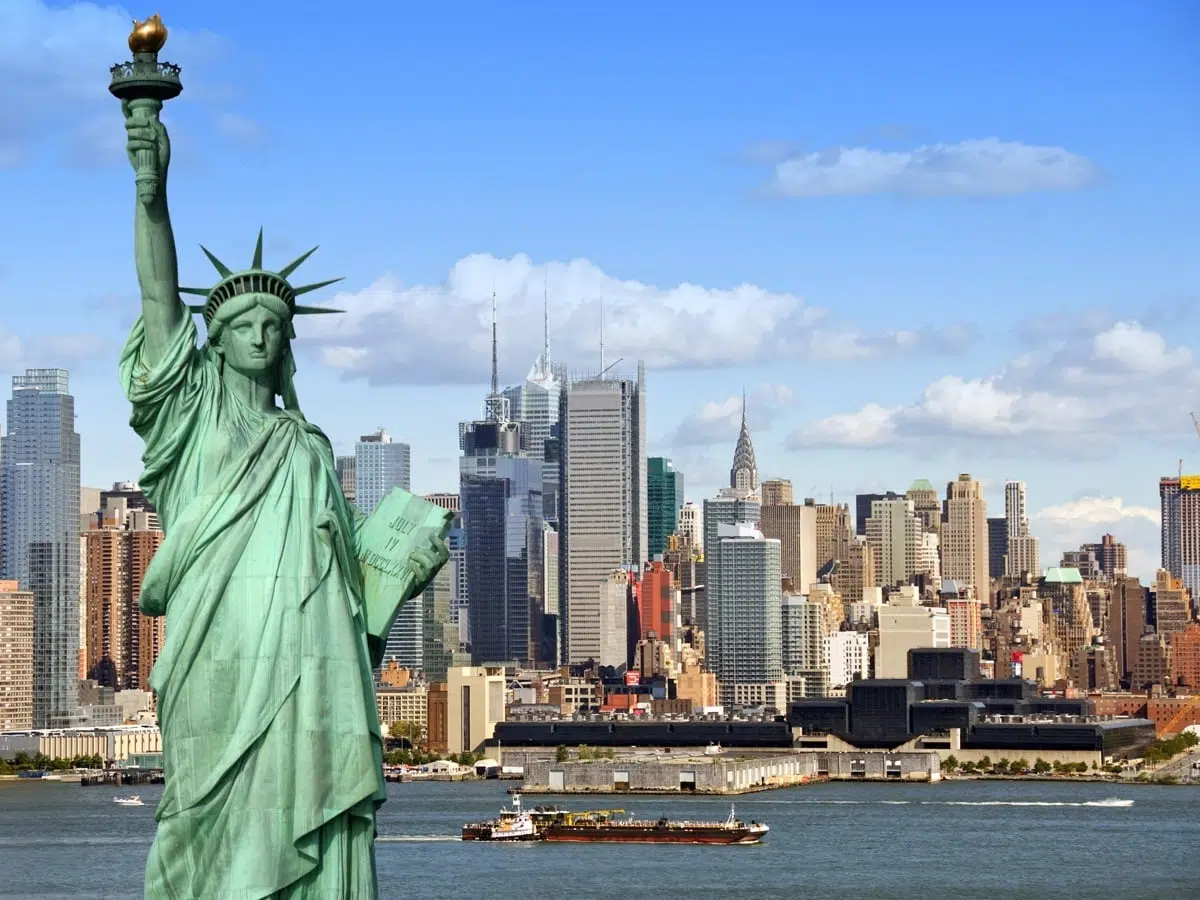
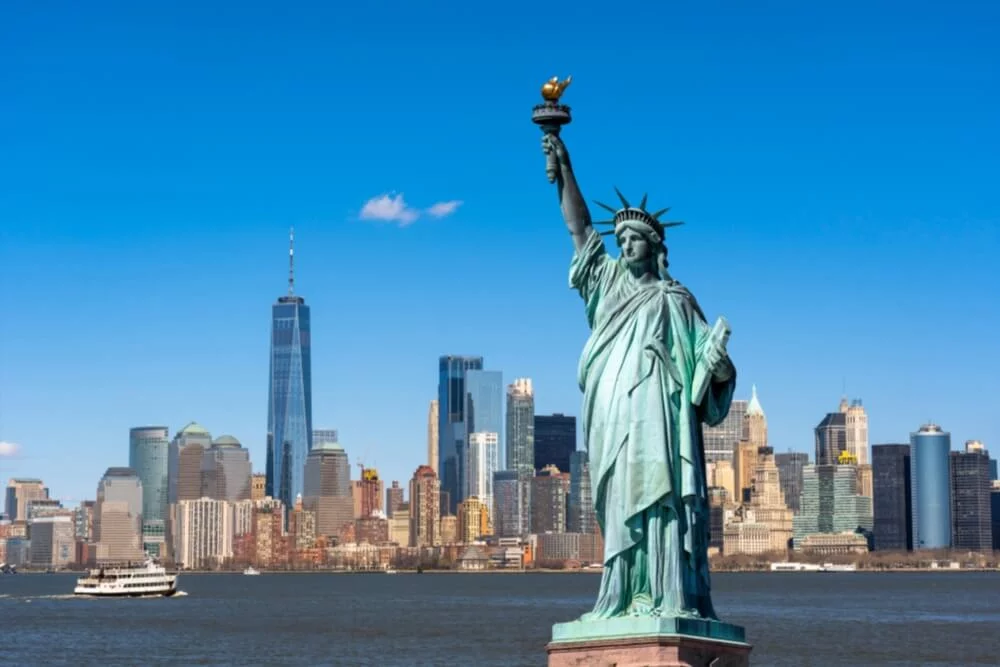
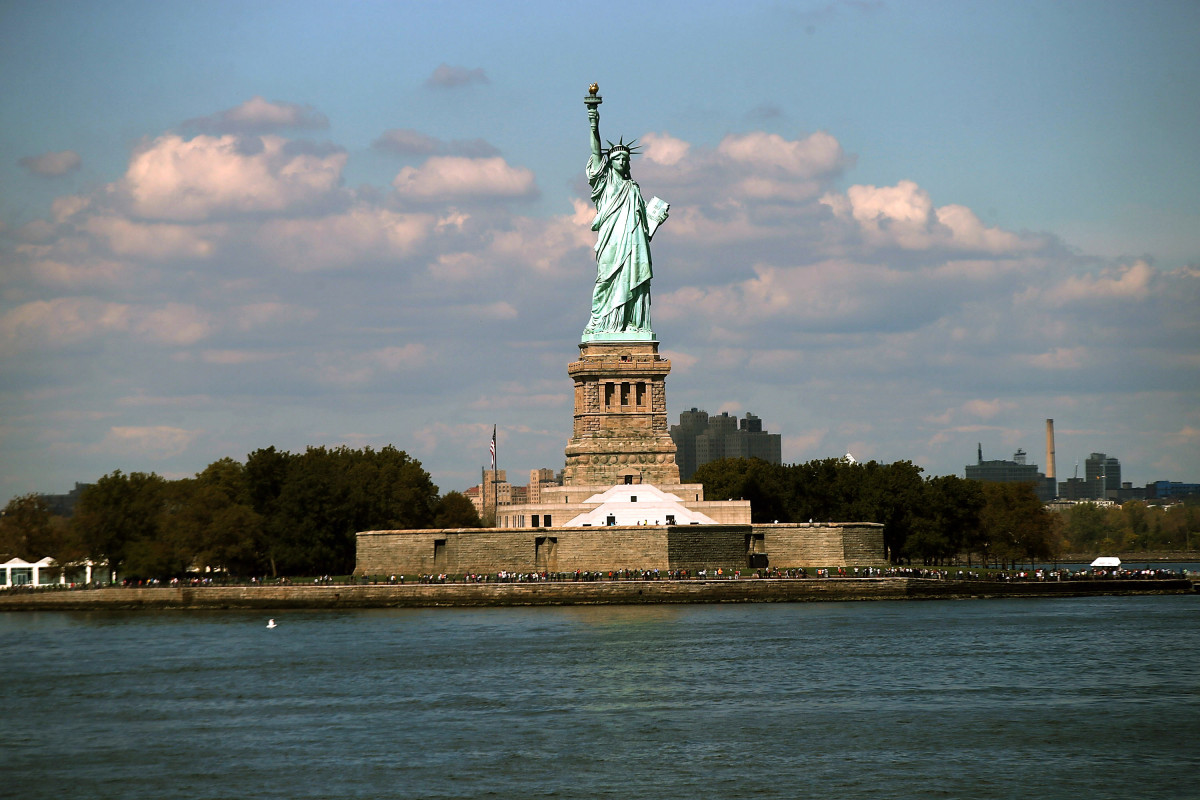

Plusieurs éléments peuvent différer d'une photo à l'autre, notamment :

- L'angle de capture (résultant d'une transformation affine ou d'une projection).
- L'orientation (résultat d'une rotation).
- L'échelle (résultat d'un zoom).
- Les propriétés photométriques, telles que la luminosité et le contraste, qui varient en fonction de l'heure de la journée, de la météo, de l'utilisation du flash...
- L'occultation, où une partie de l'image est cachée.
- Les éléments de confusion de l'arrière-plan, où une partie de l'image peut se mêler avec des éléments situés en arrière-plan.

Nous avons examiné dans cette formation diverses méthodes pour transformer une image en une autre. Parmi celles-ci, nous avons étudié les transformations géométriques, qui altèrent la disposition des pixels, ainsi que les manipulations d'histogrammes, qui permettent de corriger la luminosité et le contraste.

Lorsque deux images appartiennent à la même catégorie, c'est-à-dire qu'elles représentent la même chose, elles sont inévitablement liées par une transformation. Cependant, la caractérisation précise de cette transformation demeure inconnue.

Comment peut-on déterminer la transformation qui permet de passer d'une image à une autre ? C'est là qu'intervient un problème classique en vision par ordinateur, appelé "image matching," qui trouve des applications dans la création de panoramas, la détection d'images similaires, la reconnaissance d'objets dans une image...

Au lieu de chercher à élaborer une équation mathématique précise pour la transformation (ce que nous faisons quand nous définissions nos filtres), l'approche adoptée consiste à identifier les éléments communs aux deux images. La question fondamentale devient alors la suivante : quels sont les caractéristiques distinctives de l'image 1, et sont-elles présentes dans l'image 2 ?

Cette tâche peut sembler relativement simple pour notre cerveau, mais elle représente un défi de taille pour un ordinateur, qui doit être en mesure de décrire les spécificités d'une catégorie d'images malgré les variations potentielles énumérées précédemment.

Même si nous n'allons pas déterminer d'équation explicite de la transformation, l'approche repose malgré tout sur le principe de filtrage. Dans les sections précédentes, nous avons introduit les filtres comme des instruments efficaces pour réduire le bruit dans une image. Ils sont aussi utilisés pour repérer des motifs spécifiques. Ces motifs sont généralement exprimés sous forme de petites images appelées "templates." L'objectif du template matching est de localiser ces templates au sein d'une image donnée.

Lorsqu'on applique le template matching avec des filtres, on recourt à l'opérateur de corrélation croisée, noté ⊗. Cet opérateur opère en transformant une image représentée sous forme matricielle, notée $ X $, en une nouvelle image, nommée $ Y $, selon la formule suivante :

$ Y_{i,j} = \sum \limits_{u=−k}^{k} \sum \limits_{v=−k}^{k} H_{u,v} X_{i+u,j+v} $

Dans ce contexte, $ H $ désigne une petite image (pour les physiciens, penser "imagette" en analogie au principe "d'ondelette" pour plus tard) qui représente le template que l'on cherche à localiser. En pratique, cette opération se résume à déplacer le template $ H $ sur l'image $ X $, en multipliant les pixels qui se chevauchent et en additionnant les produits obtenus.

La formule de la corrélation croisée ressemble au produit de convolution. <font color="orange">Quelle est la différence entre ces deux opérateurs ?</font>

In [18]:
# Votre réponse ici

<font color="orange">Charger les images charlie_template et charlie_scene, les convertir en niveaux de gris et les visualiser. Afficher leur taille.</font>

In [19]:
# Votre code ici

<font color="orange">C'est l'heure de jouer sans tricher : indiquer un ordre de grandeur de la position du template dans l'image.</font>

In [20]:
# Votre réponse ici

<font color="orange">Trouver dans le module feature de scikit-image la fonction la plus adaptée pour faire du template matching. L'appliquer aux images de Où est Charlie et visualiser la sortie (la carte de corrélation).</font>

In [21]:
# Votre code ici

<font color="orange">Repérer le point de cross-correlation maximale dans cette sortie.</font>

In [22]:
# Votre code ici

<font color="orange">Faire apparaître le template en niveaux de gris sur une image au fond noir, au niveau de sa position sur l'image de départ.</font>

In [23]:
# Votre code ici

<font color="orange">Rassembler les éléments de code précédents dans une fonction prenant en entrée une image et un template, renvoyant la position du template dans l'image tout en affichant le template gris sur le fond noir comme précédemment.</font>

In [44]:
def find_charlie(scene_array: np.ndarray, template_array: np.ndarray) -> tuple[int, int]:
    try:
        grey_scene_array = color.rgb2gray(scene_array)
    except ValueError:
        grey_scene_array = scene_array
    try:
        grey_template_array = color.rgb2gray(template_array)
    except ValueError:
        grey_template_array = template_array
        
    corr_map_array = feature.match_template(grey_scene_array, grey_template_array)
    y, x = np.unravel_index(np.argmax(corr_map_array), corr_map_array.shape)
    
    masked_array = np.zeros(grey_scene_array.shape)
    y_template, x_template = grey_template_array.shape
    masked_array[y: y + y_template, x: x + x_template] = grey_template_array
    
    plt.imshow(masked_array, cmap= "gray")
    plt.show()
    
    return y, x

<font color="orange">L'appeler sur Charlie.</font>

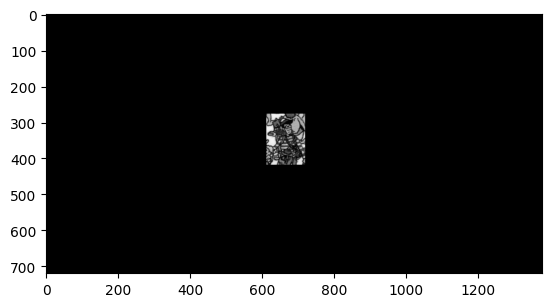

(np.int64(277), np.int64(613))

In [43]:
scene_array_1 = io.imread(r"../../data/charlie/charlie_scene.jpg")
template_array_1 = io.imread(r"../../data/charlie/charlie_template.jpg")
find_charlie(scene_array=scene_array_1, template_array=template_array_1)

<font color="orange">L'essayer sur le cas Charlie 2.</font>

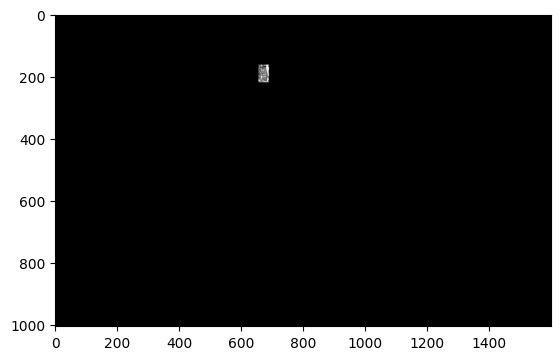

(np.int64(163), np.int64(655))

In [ ]:
scene_array_2 = io.imread(r"../../data/charlie/charlie_scene_2.jpg")
template_array_2 = io.imread(r"../../data/charlie/charlie_template_2.jpg")
find_charlie(scene_array=scene_array_2, template_array=template_array_2)

Il est temps de chercher ouaf. <font color="orange">Essayer la fonction sur le cas Charlie 3.</font>

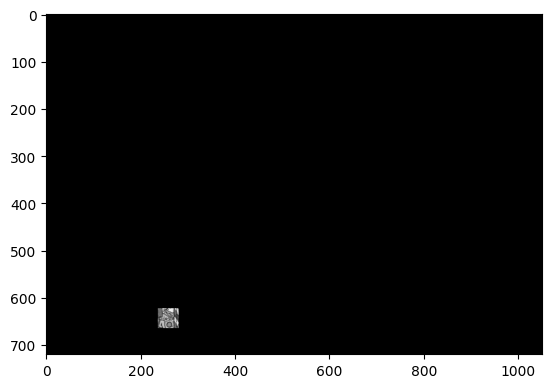

(np.int64(623), np.int64(237))

In [47]:
scene_array_3 = io.imread(r"../../data/charlie/charlie_scene_3.jpg")
template_array_3 = io.imread(r"../../data/charlie/charlie_template_3.jpg")
find_charlie(scene_array=scene_array_3, template_array=template_array_3)

<font color="orange">Commenter les limites de nos filtres Charlie.</font>

In [28]:
# Votre réponse ici

 C'est à ce stade que la notion de "features" (caractéristiques) d'une image entre en jeu. Ce terme fait référence à des zones spécifiques d'une image numérique qui suscitent un intérêt particulier. Ces zones peuvent correspondre à des contours, des points saillants ou des régions d'intérêt. Chaque feature détectée est associée à un vecteur appelé "descripteur" (ou "feature descriptor" / "feature vector"). Comme son nom l'indique, ce descripteur renferme des informations pour caractériser la zone en question.

La résolution du problème d'image matching s'articule alors autour de deux étapes principales :

- La détection et la description des features dans chaque image.
- La recherche de paires de features correspondantes dans les deux images (appelée "features matching").

La qualité des résultats obtenus grâce à l'algorithme d'image matching repose sur la pertinence des features détectées. En ce sens, la première étape revêt une importance cruciale et ne doit pas être négligée.

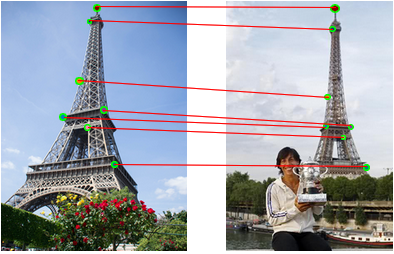

La détection et la description des features constituent la première étape indispensable pour de nombreuses tâches en computer vision, y compris la classification d'images, que nous étudierons plus en détail durant la formation dans un prochain TP.


Naturellement, un choix inadéquat de features peut entraîner deux problèmes majeurs lors de l'étape de matching :

- Deux images peuvent ne pas avoir les mêmes features, même si elles représentent la même scène de différentes manières.
- Deux images peuvent présenter les mêmes features, mais il peut être extrêmement difficile de trouver les paires correspondantes entre elles.

Ces deux problèmes peuvent rendre le matching impossible, et c'est pourquoi il est essentiel d'anticiper ces défis dès la première étape, lors de la détection et de la description des features.

Cela nous amène à la question fondamentale : quelles features faut-il sélectionner ?

Les features appropriées doivent répondre à plusieurs critères :

- <b>Répétabilité</b> : Les features doivent être reconnaissables dans les images représentant la même scène, malgré les variations géométriques et photométriques. Elles doivent donc être invariantes à ces transformations.
- <b>Distinctivité</b> : Les features doivent être uniques et clairement identifiables au sein d'une image pour faciliter le matching. Les informations contenues dans leur descripteur doivent mettre en évidence leur singularité.
- <b>Localité</b> : Les features doivent correspondre à des zones de taille suffisamment réduite et doivent être décrites en fonction de leur voisinage immédiat. Cela permet de surmonter les problèmes liés à l'occlusion et aux éléments de confusion en arrière-plan.
- <b>Abondance</b> : Un grand nombre de features détectées est souhaitable, mais il est essentiel que leur nombre total reste inférieur au nombre de pixels de l'image pour garantir l'efficacité de l'algorithme de matching.

En résumé, pour être considérée comme une "bonne" feature, une caractéristique doit être à la fois suffisamment distinctive pour différencier des classes d'images différentes et suffisamment générique pour permettre la reconnaissance aisée d'images de la même classe, malgré les variations dans leurs représentations.

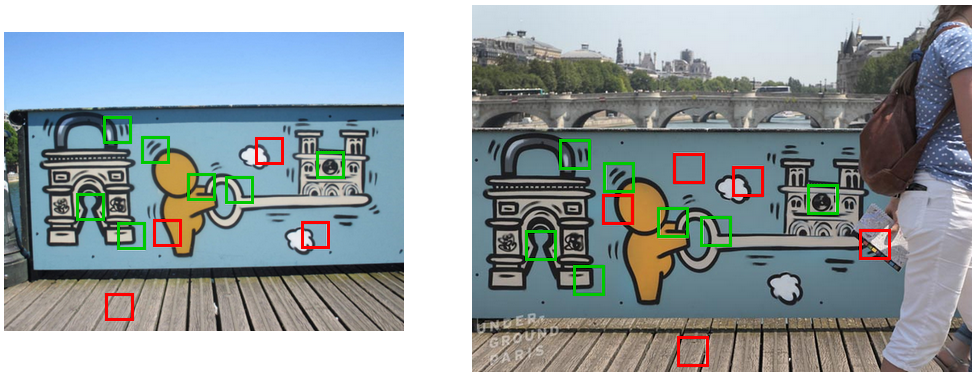

### Gradient

Cette section peut être passée par les personnes qui ne sont pas particulièrement intéressées par les quelques aspects mathématiques derrière la création pratique de features ou, au contraire, ceux qui sont familiers avec cette notion de gradient.

Le gradient d'une image est un outil précieux pour détecter des caractéristiques. Il s'agit d'un vecteur composé des dérivées partielles de la fonction d'intensité calculées pour chaque pixel :

$ ∇I(x, y) = \begin{bmatrix} \frac{∂I(x, y)}{∂x} \\ \frac{∂I(x, y)}{∂y} \end{bmatrix}$

La dérivée partielle par rapport à x (respectivement y) nous permet d'analyser les variations d'intensité de l'image le long de l'axe des abscisses (respectivement des ordonnées).

Le gradient pointe dans la direction où l'intensité varie le plus dans le voisinage du pixel (x, y) :
$ Θ = \arctan(\frac{\frac{∂I(x, y)}{∂y}}{\frac{∂I(x, y)}{∂x}}) $

Sa norme indique à quel point cette variation est significative (plus elle est élevée, plus le changement est brusque) :
$ ||∇I(x, y)|| = \sqrt{(\frac{∂I(x, y)}{∂x})^2 + (\frac{∂I(x, y)}{∂y})^2} $




<font color="orange">Proposer une expression approchée du gradient en un pixel à partir des intensités des pixels de son voisinage (différences finies). En déduire deux masques de convolution ou corrélation croisée qui permettent de calculer les deux composantes de ce gradient.</font>

In [29]:
# Votre réponse ici

<font color="orange">Imaginer une version de ces noyaux en taille 3x3 de sorte à "lisser" les variations en utilisant également la ligne du dessus et celle d'en dessous pour le gradient selon $ x $, mais pondérées deux fois moins que la ligne du pixel considéré, et de même avec les colonnes de gauche et de droite pour le gradient selon $ y $.</font>

In [30]:
# Votre code ici

Bravo, vous venez de retrouver précisément le filtre de Sobel, très utilisé lorsqu'on a besoin d'approximer le gradient !

<font color="orange">Essayer d'imaginer une application de ce gradient pour la détection d'objets.</font>

In [31]:
# Votre réponse ici

### Détection de bords

Et c'est précisément ce qu'il se passe dans le filtre de Canny que nous avons utilisé en début de TP !

Vu que les valeurs élevées de l'amplitude du gradient indiquent des changements d'intensité importants l'objectif est de localiser les maxima locaux de la norme du gradient ||∇I||.

Le processus de détection des bords à l'aide du filtre de Canny comporte différentes étapes :

1- Réduction du bruit : Tout d'abord, il est essentiel de réduire le bruit de l'image, car les pixels ayant des valeurs aberrantes peuvent entraîner des variations d'intensité importantes qui ne correspondent pas nécessairement à des bords. On utilise généralement un filtre gaussien pour éliminer le bruit additif et un filtre médian pour les rares "pixels poivre et sel".

2- Calcul du gradient de l'image : Le gradient de l'image débruitée est obtenu en effectuant une opération de convolution, généralement avec les masques de Sobel. Cela permet de calculer l'amplitude et la direction du gradient en chaque point de l'image. Les bords sont identifiés grâce aux points présentant une forte amplitude.

3- Suppression des non-maxima : Les bords identifiés à l'étape précédente sont parfois trop épais. Afin de les affiner, on ne conserve que les points où l'amplitude du gradient est localement maximale dans la direction du gradient. Pour ce faire, on quantifie l'angle de la direction du gradient et on identifie les deux voisins de chaque pixel le long de cette direction.

4- Seuillage : Parmi les points sélectionnés à l'étape précédente, seuls ceux dont l'amplitude du gradient est supérieure à un certain seuil sont conservés. Le choix d'un seuil adéquat peut être délicat, c'est pourquoi on utilise souvent le seuillage par hystérésis, qui repose sur deux seuils, $ s_{bas} $ et $ s_{haut} $.
    - Si ||∇I(x,y)|| ≥ $ s_{haut} $, alors le pixel (x,y) est considéré comme étant sur un bord.
    - Si ||∇I(x,y)|| ≥ $ s_{bas} $, alors le pixel (x,y) est identifié comme étant sur un bord si au moins l'un de ses huit voisins l'est également.
    - Sinon, le pixel (x,y) n'est pas considéré comme faisant partie d'un bord.

<font color="orange">Tout à l'heure, nous avions appliqué le filtre de Canny sur une image peu bruitée. A votre avis, l'implémentation de scikit-image effectue-t-elle un lissage de bruit ou faut-il le réaliser soi-même avant d'appliquer la méthode à proprement parler ?</font>

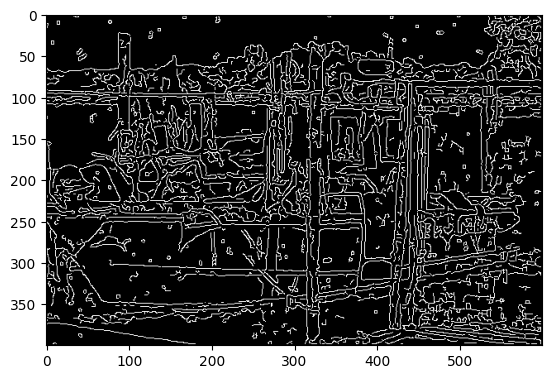

In [63]:
canny_array = feature.canny(masked_array, sigma=1.5)
plt.imshow(canny_array, cmap="gray")
plt.show()

### Détection de coins

Les coins sont des features très riches en informations. Leur détection est basée sur le même principe que celle des contours, mais dans le cas d'un coin, l'intensité varie dans deux directions peu colinéaires.

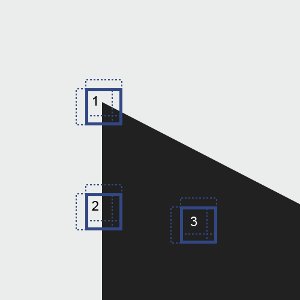

1- Dans la première situation, si la zone contient un coin, l'intensité de l'image change brusquement dans plusieurs directions, ce qui se traduit par des valeurs élevées de la fonction E dans ces différentes directions.

2- Dans la deuxième situation, si la zone contient un contour, l'intensité de l'image change rapidement en se déplaçant horizontalement, mais très peu en se déplaçant verticalement. En conséquence, la fonction E présente des valeurs élevées lorsque le déplacement est perpendiculaire au contour, mais des valeurs faibles lorsqu'il suit le contour.

3- Enfin, dans la troisième situation, en l'absence de changements d'intensité, c'est-à-dire lorsque la région est uniforme, la fonction E affiche des valeurs faibles dans toutes les directions.

On a décrit ici le principe de base du filtre de Moravec.

Un des filtres de détection de coins les plus célèbres est celui de Harris-Stephens. Il s'agit d'une amélioration du filtre de Moravec. Pour les plus curieux, voici en quoi :
- la fenêtre carrée centrée visible sur le schéma du dessus est remplacée par une fenêtre gaussienne,
- les variations d'intensité qui interviennent dans le calcul sont approximées par les dérivées partielles (développement de Taylor) elles-mêmes approximées par des filtres de Sobel vus précédemment, au lieu d'être calculées directement,
- un nouveau critère (basé sur le calcul des deux valeurs propres d'une matrice) est introduit pour déterminer si nous sommes face à un coin, un bord ou une région plate.

<font color="orange">Sur l'image de notre bateau, repérer la ou les zone(s) avec des coins très marqués. En sachant que coin se dit "corner" en anglais, trouver la fonction du module feature de scikit-image permettant de réaliser un filtre de Harris-Stephens (parfois simplement appelé filtre de Harris). Visualiser le résultat.</font>

In [ ]:
corner_array = feature.corner_harris(img_gray_array, sigma=1)
plt.imshow(corner_array)
plt.show()